## 1. KNN for classification and regression

a) Use KNN to classify iris dataset 

b) Use KNN to predict house prices for the dataset you used in exercise1 

# a) Use KNN to classify iris dataset

In [2]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["iris_class"] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris_class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## divide data into features X and target y

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

X, y = df.drop("iris_class", axis=1), df["iris_class"]
X.shape, y.shape

((150, 4), (150,))

## train|test split data

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
X_train.shape, X_test.shape

((100, 4), (50, 4))

## scale data

In [8]:
scaler = MinMaxScaler()
scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

print(f"{scaled_X_train.mean() = }")
print(f"{scaled_X_train.std() = }")
print(f"{scaled_X_train.min() = }")
print(f"{scaled_X_train.max() = }\n")
print(f"{scaled_X_test.mean() = }")
print(f"{scaled_X_test.std() = }")
print(f"{scaled_X_test.min() = }")
print(f"{scaled_X_test.max() = }")

scaled_X_train.mean() = np.float64(0.464095922459893)
scaled_X_train.std() = np.float64(0.2682348708449146)
scaled_X_train.min() = np.float64(0.0)
scaled_X_train.max() = np.float64(1.0)

scaled_X_test.mean() = np.float64(0.4722276865291571)
scaled_X_test.std() = np.float64(0.2811387418098403)
scaled_X_test.min() = np.float64(-0.017857142857142877)
scaled_X_test.max() = np.float64(1.0909090909090908)


## predict data

In [9]:
model = KNeighborsClassifier()

model.fit(scaled_X_train, y_train)

y_pred = model.predict(scaled_X_test)

y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0,
       0, 1, 1, 2, 1, 2])

In [10]:
y_test.values 

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0,
       0, 1, 2, 2, 1, 2])

In [11]:
y_pred - y_test.values 

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0])

## evaluate data

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.94      1.00      0.97        15
           2       1.00      0.94      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



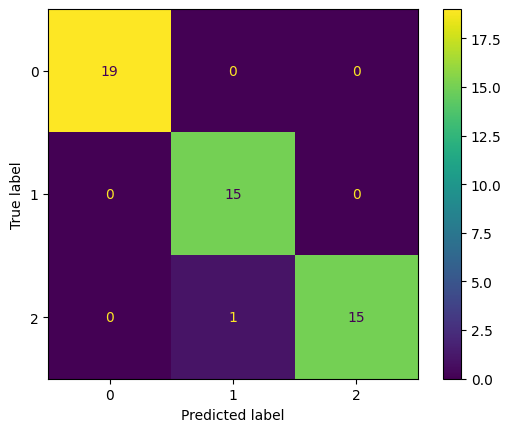

In [12]:
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot();

# b) Use KNN to predict house prices for the dataset you used in exercise1 

In [17]:
df = pd.read_csv("../../data/house_data.csv")
df = df.query("price > 0")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [24]:
df.drop(["date", "street", "city", "statezip", "country"], axis=1, inplace=True)

<Axes: >

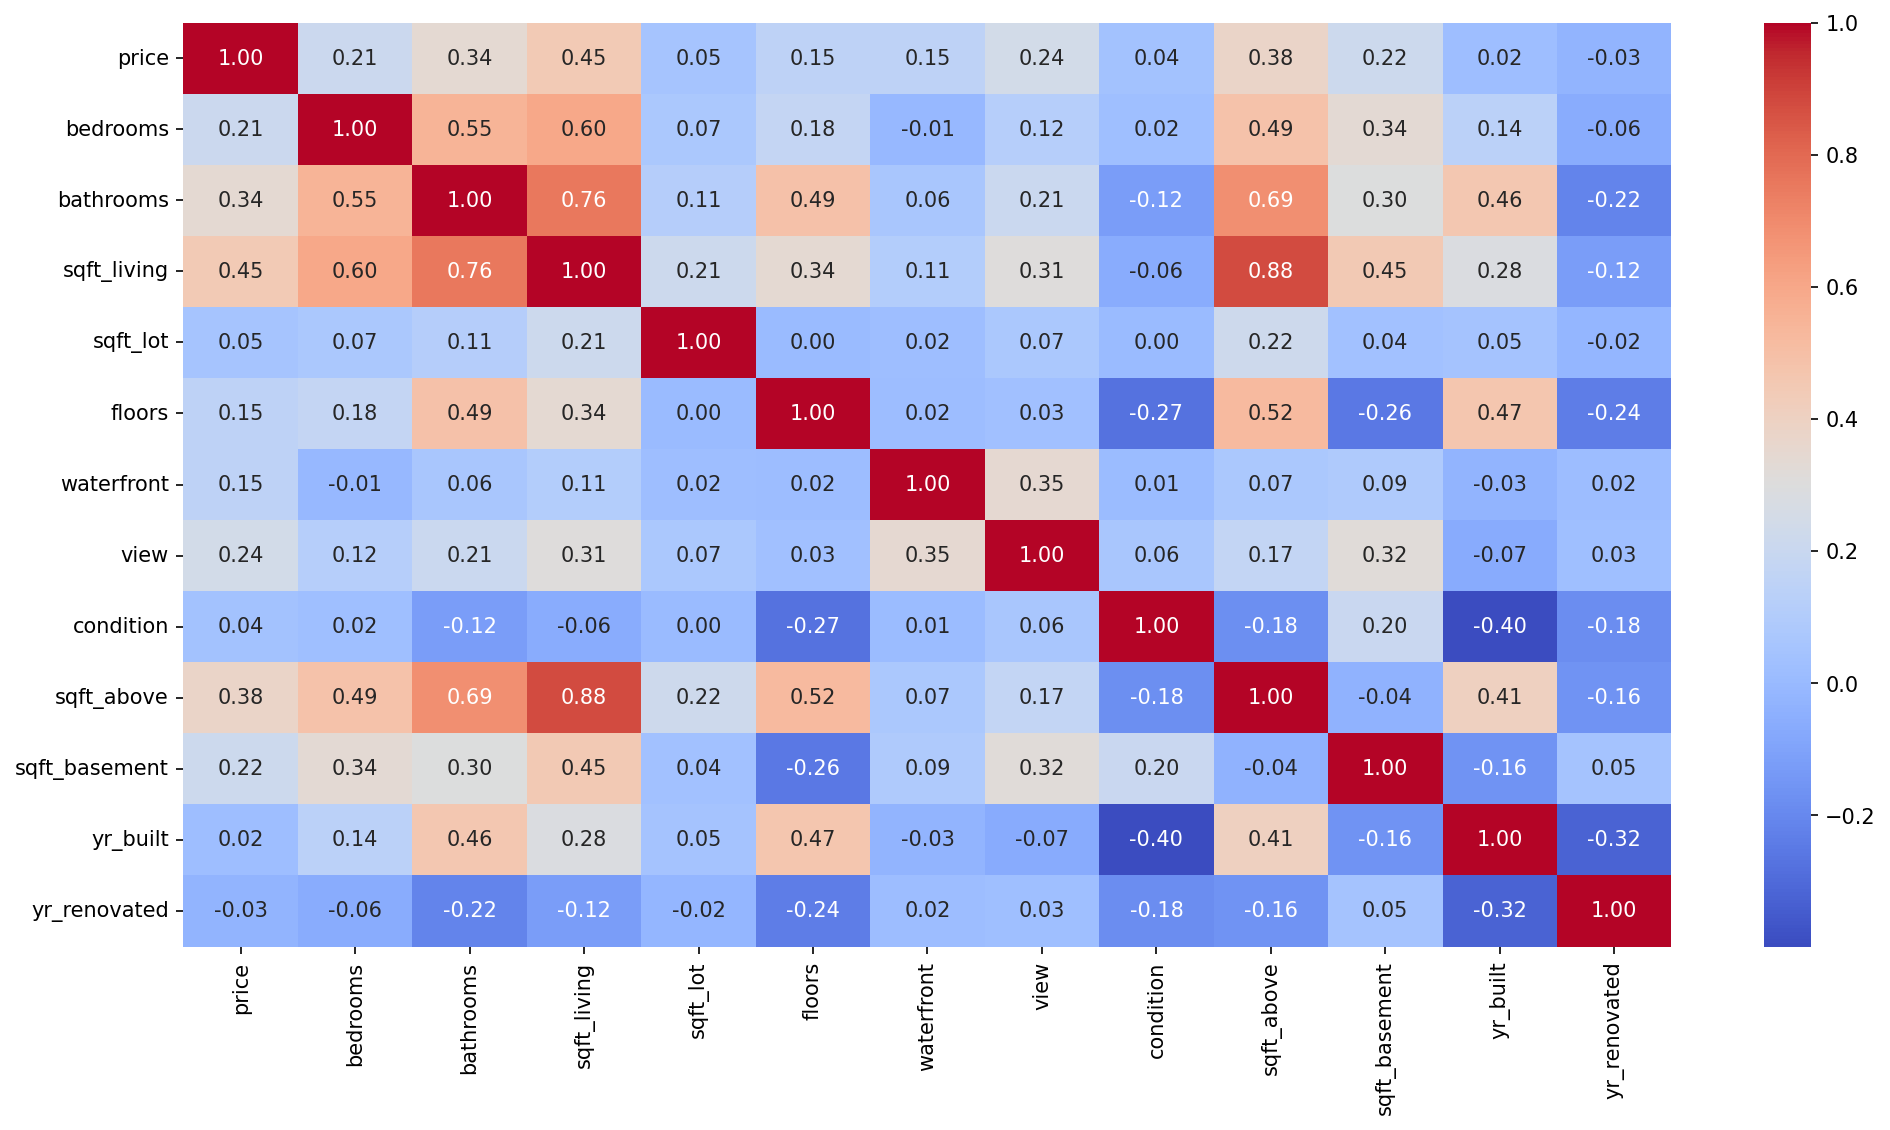

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, figsize=(16,8), dpi=150)

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

<Axes: >

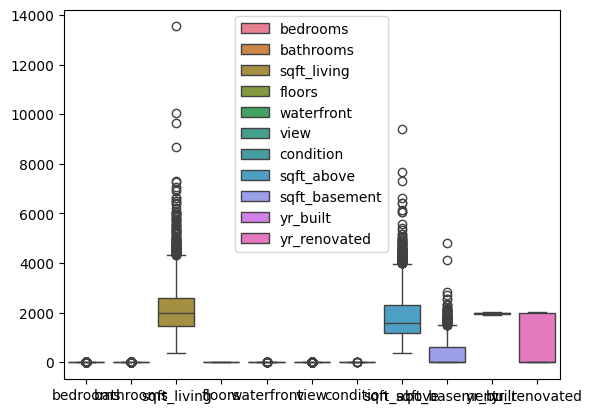

In [34]:
sns.boxplot(df.drop(["price", "sqft_lot"], axis=1), legend=True)

In [25]:
X, y = df.drop("price", axis=1), df["price"]
X.shape, y.shape

((4551, 12), (4551,))

## train|test split

In [ ]:
# Första split: Train och Test
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_full.shape, X_test.shape

((3640, 12), (911, 12))

## train|val|test split

In [42]:
# Första split: Train och Test
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Andra split: Train och Validation
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)
# (0.25 av 0.8 ≈ 0.2, så totalt blir det 60% train, 20% val, 20% test)

X_train.shape, X_val.shape, X_test.shape, len(X_train) + len(X_val) + len(X_test), X.shape

((2730, 12), (910, 12), (911, 12), 4551, (4551, 12))

In [46]:
scaler = MinMaxScaler()
scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)
scaled_X_val = scaler.transform(X_val)

print(f"{scaled_X_train.mean() = }")
print(f"{scaled_X_train.std() = }")
print(f"{scaled_X_train.min() = }")
print(f"{scaled_X_train.max() = }\n")
print(f"{scaled_X_test.mean() = }")
print(f"{scaled_X_test.std() = }")
print(f"{scaled_X_test.min() = }")
print(f"{scaled_X_test.max() = }")

scaled_X_train.mean() = np.float64(0.2668753420514059)
scaled_X_train.std() = np.float64(0.2865670360610697)
scaled_X_train.min() = np.float64(0.0)
scaled_X_train.max() = np.float64(1.0)

scaled_X_test.mean() = np.float64(0.27423581682942677)
scaled_X_test.std() = np.float64(0.2919618558897141)
scaled_X_test.min() = np.float64(-0.008319467554076546)
scaled_X_test.max() = np.float64(1.9153284671532849)


In [49]:
y_train

3251    395000.000000
2119    305100.000000
610     287600.000000
2680    840000.000000
772     765000.000000
            ...      
4475    458663.888889
1638    427000.000000
2314    465000.000000
3445    358000.000000
3323    645000.000000
Name: price, Length: 2730, dtype: float64

## decide k value for actual model

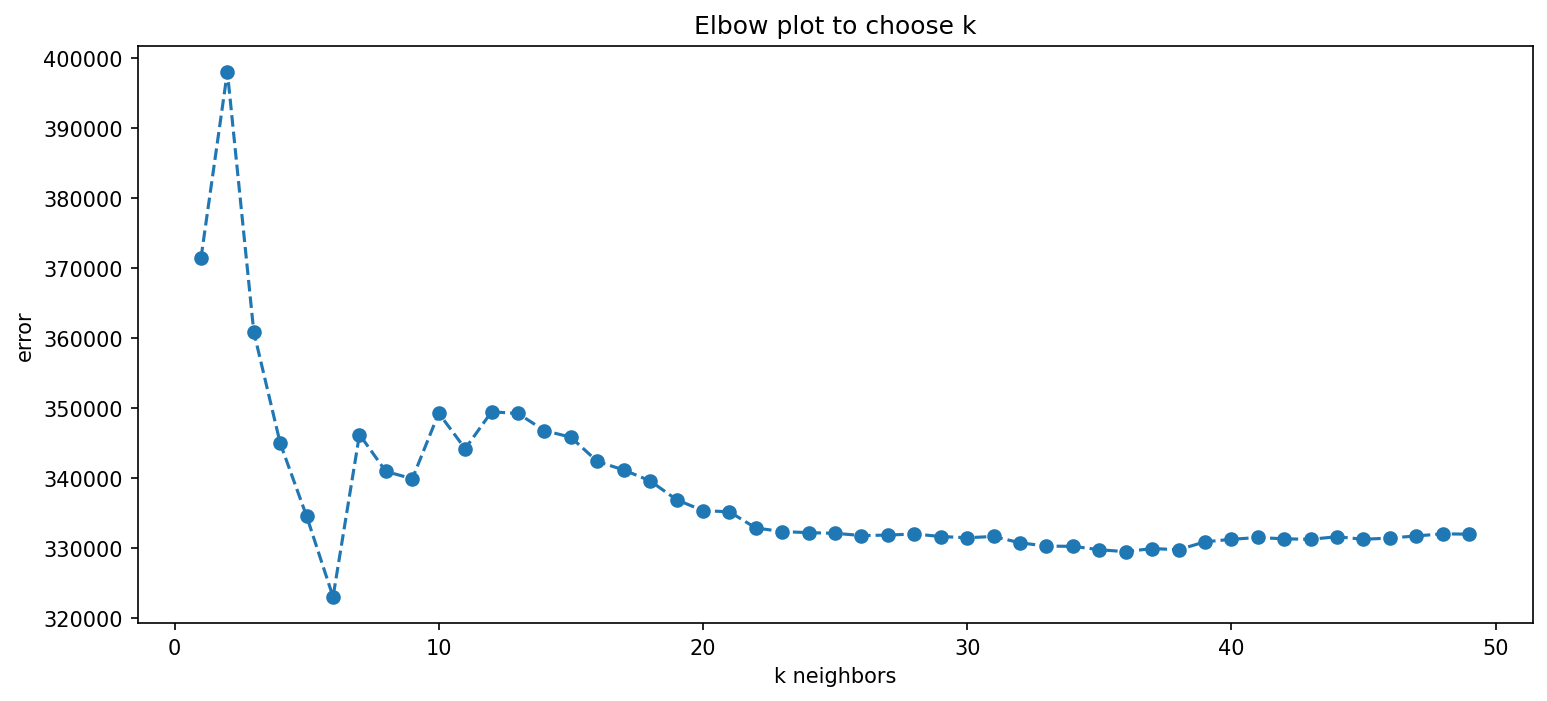

In [62]:
from sklearn.metrics import accuracy_score, root_mean_squared_error
from sklearn.neighbors import KNeighborsRegressor

error_list = []
for k in range(1,50):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(scaled_X_train, y_train)
    y_pred = model.predict(scaled_X_val)
    error = root_mean_squared_error(y_val, y_pred)
    error_list.append(error)

fig, ax = plt.subplots(1, figsize=(12,5), dpi=150)
plt.plot(range(1,50), error_list, '--o')
ax.set(xlabel="k neighbors", ylabel="error", title="Elbow plot to choose k");

In [64]:
best_rmse = min(error_list)
best_index = error_list.index(best_rmse)
k = best_index+1

## final model

In [67]:
from sklearn.preprocessing import StandardScaler

final_scaler = StandardScaler()
final_scaler.fit(X_train_full)

scaled_full_X_train = final_scaler.transform(X_train_full)
scaled_X_test = final_scaler.transform(X_test)

In [69]:
final_model = KNeighborsRegressor(n_neighbors=k)
final_model.fit(scaled_full_X_train, y_train_full)
y_pred = final_model.predict(scaled_X_test)
final_model.score(scaled_X_test, y_test) # 33% rätt

0.3906956575361368

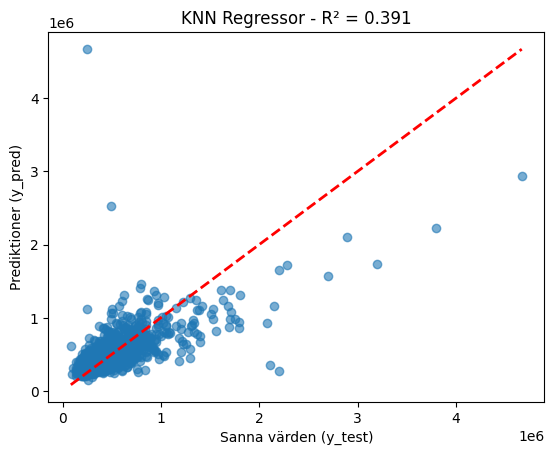

In [70]:
from sklearn.metrics import r2_score

# Rita scatterplot
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)  # perfekt linje y = x

plt.xlabel("Sanna värden (y_test)")
plt.ylabel("Prediktioner (y_pred)")
plt.title(f"KNN Regressor - R² = {r2_score(y_test, y_pred):.3f}")
plt.show()

c:\Users\organ\Repos\ml_ai\ai_engineering_pontus_agren_grundstrom\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(


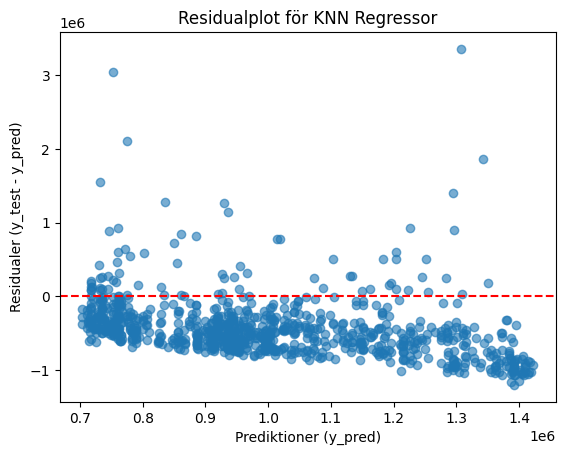

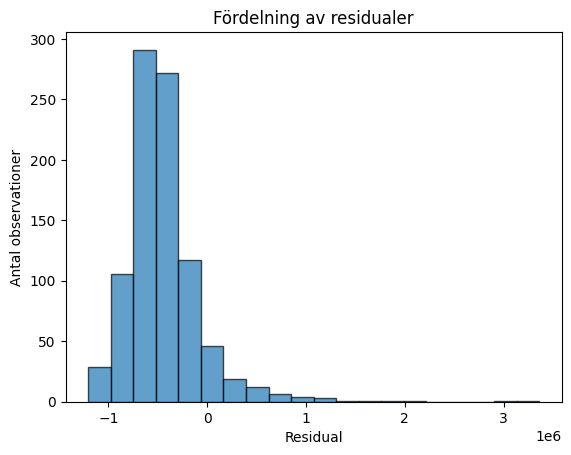

In [71]:
import numpy as np

# Beräkna residualer
y_pred = model.predict(X_test)
residuals = y_test - y_pred

# Scatterplot: y_pred vs residuals
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')  # referenslinje
plt.xlabel("Prediktioner (y_pred)")
plt.ylabel("Residualer (y_test - y_pred)")
plt.title("Residualplot för KNN Regressor")
plt.show()

# Histogram: för att se fördelning av residualer
plt.hist(residuals, bins=20, edgecolor='k', alpha=0.7)
plt.xlabel("Residual")
plt.ylabel("Antal observationer")
plt.title("Fördelning av residualer")
plt.show()